In [1]:
! pip install lightning --quiet
! pip install wandb --quiet
! pip install hydra-core --upgrade
!pip install --upgrade sympy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.0/846.0 kB 18.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 57.7 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: sympy
    Found existing installation: sympy 1.13.3
    Uninstalling sympy-1.13.3:
      Successfully uninstalled sympy-1.13.3


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms
import torchvision
import os
from tqdm.notebook import tqdm


import pandas as pd

# =========================
# Standard library imports
# =========================
import os
import os.path as osp
import math
import random
import zipfile
from datetime import datetime
from collections import OrderedDict

# =========================
# Third-party libraries
# =========================
import numpy as np
from PIL import Image, ImageDraw

import gdown
import wandb

# =========================
# PyTorch and TorchVision
# =========================
import torch
from torch import nn, tensor
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Subset
from torch.utils.tensorboard import SummaryWriter

import torchvision
from torchvision import transforms
from torchvision.datasets import MNIST, CIFAR10

# =========================
# PyTorch Lightning
# =========================

import lightning as L
from lightning.pytorch import Trainer, seed_everything
from lightning.pytorch.loggers import TensorBoardLogger, WandbLogger
from lightning.pytorch.callbacks import Callback, ModelCheckpoint, EarlyStopping, LearningRateMonitor
import torchmetrics

from torchmetrics.classification import accuracy

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [3]:
!gdown 17PBT__KLwJuAsUMSxnByGWaBkMaxGh4i

Downloading...
From (original): https://drive.google.com/uc?id=17PBT__KLwJuAsUMSxnByGWaBkMaxGh4i
From (redirected): https://drive.google.com/uc?id=17PBT__KLwJuAsUMSxnByGWaBkMaxGh4i&confirm=t&uuid=3bc49370-ffd4-4b64-8274-074b5294ae72
To: /kaggle/working/MGCD.zip
100%|█████████████████████████████████████████| 575M/575M [00:04<00:00, 133MB/s]


In [4]:
! makdir MGCD
!unzip MGCD.zip -d MGCD

/bin/bash: line 1: makdir: command not found
Archive:  MGCD.zip
   creating: MGCD/MGCD/
   creating: MGCD/MGCD/test/
   creating: MGCD/MGCD/test/1_cumulus/
  inflating: MGCD/MGCD/test/1_cumulus/1_cumulus_000691.jpg  
  inflating: MGCD/MGCD/test/1_cumulus/1_cumulus_000692.jpg  
  inflating: MGCD/MGCD/test/1_cumulus/1_cumulus_000693.jpg  
  inflating: MGCD/MGCD/test/1_cumulus/1_cumulus_000694.jpg  
  inflating: MGCD/MGCD/test/1_cumulus/1_cumulus_000695.jpg  
  inflating: MGCD/MGCD/test/1_cumulus/1_cumulus_000696.jpg  
  inflating: MGCD/MGCD/test/1_cumulus/1_cumulus_000697.jpg  
  inflating: MGCD/MGCD/test/1_cumulus/1_cumulus_000698.jpg  
  inflating: MGCD/MGCD/test/1_cumulus/1_cumulus_000699.jpg  
  inflating: MGCD/MGCD/test/1_cumulus/1_cumulus_000700.jpg  
  inflating: MGCD/MGCD/test/1_cumulus/1_cumulus_000701.jpg  
  inflating: MGCD/MGCD/test/1_cumulus/1_cumulus_000702.jpg  
  inflating: MGCD/MGCD/test/1_cumulus/1_cumulus_000703.jpg  
  inflating: MGCD/MGCD/test/1_cumulus/1_cumulus_000

In [5]:
train_dataset_path = '/kaggle/working/MGCD/MGCD/train'
test_dataset_path = '/kaggle/working/MGCD/MGCD/test'



In [6]:
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split
from torchvision.transforms import Resize, Compose, ToTensor, Normalize

image_size = (256, 256)
imagenet_transform = Compose([Resize(image_size), ToTensor(), Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])




In [7]:
dataset = ImageFolder(train_dataset_path, transform=imagenet_transform)


test_dataset = ImageFolder(test_dataset_path, transform=imagenet_transform)

In [8]:
train_dataset_size = int(len(dataset) * 0.9)
train_dataset, val_dataset = random_split(dataset, [train_dataset_size, len(dataset) - train_dataset_size])

In [9]:
from torchvision.transforms import ToPILImage
import PIL
from IPython.display import display

# Przekształcenie odwrotne do normalizacji tesnora
inv_imagenet_normalize = Normalize(mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225], std=[1./0.229, 1./0.224, 1./0.225])

def tensor_to_image(tensor_image):
    to_pil_image = Compose([inv_imagenet_normalize, ToPILImage()])
    image = to_pil_image(tensor_image)
    return image

1


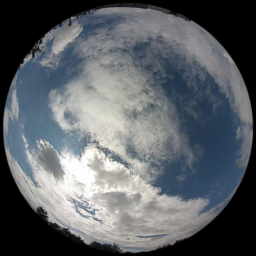

In [10]:
tensor_image, label = dataset[1000]
image = tensor_to_image(tensor_image)
print(label)
display(image)

In [11]:
from torch.utils.data import DataLoader

batch_size = 16

train_gen = DataLoader(dataset = train_dataset, batch_size = batch_size, shuffle = True)
val_gen = DataLoader(dataset = val_dataset, batch_size = batch_size,  shuffle = False)
test_gen = DataLoader(dataset = test_dataset, batch_size = batch_size, shuffle = False)

In [12]:
import os
import torch
from torch.utils.data import Dataset
import pandas as pd
from PIL import Image
from torchvision import transforms

class CloudImageTabularDataset(Dataset):
    def __init__(self, excel_path, image_path, transform=None):
        self.image_path = image_path
        self.transform = transform
        self.df = pd.read_excel(excel_path)
        # Poprawione nazwy kolumn zgodnie z Twoim zrzutem ekranu
        self.tabular_cols = ['Temperature(℃)', 'Humidity(%RH)', 'Pressure(hpa)', 'Wind speed(m/s)']

    def set_transform(self, transform):
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # --- IMAGE ---
        img_path = os.path.join(self.image_path, f"{row['Name']}.jpg")
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)
        else:
            image = transforms.functional.to_tensor(image)

        # --- TABULAR ---
        tabular_data = row[self.tabular_cols].values.astype('float32')
        tabular = torch.from_numpy(tabular_data)

        # Twoja normalizacja tabelaryczna
        TAB_MEAN = torch.tensor([30.568, 55.4607, 1008.75, 0.913], dtype=torch.float32)
        TAB_STD  = torch.tensor([5.239, 16.976, 5.532, 0.863], dtype=torch.float32)
        tabular = (tabular - TAB_MEAN) / TAB_STD

        # --- LABEL ---
        # Używamy -1 jeśli Twoje klasy w nazwach są 1-7, a PyTorch wymaga 0-6
        y = torch.tensor(int(row['Name'].split('_')[0]) - 1, dtype=torch.long)

        return image, tabular, y




In [13]:
dataset = CloudImageTabularDataset(image_path = '/kaggle/working/MGCD/MGCD/test/1_cumulus', excel_path = '/kaggle/working/MGCD/MGCD/test/1_cumulus.xlsx')
print(dataset[0])

(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]]), tensor([ 0.0825, -1.9180,  1.6721, -1.0579]), tensor(0))


In [14]:
df = pd.read_excel('/kaggle/working/MGCD/MGCD/test/1_cumulus.xlsx') # Używamy 'df' dla jasności
listt = df.iloc[1, 0:]
print(int(listt['Name'].split('_')[0]))

1


In [15]:
import lightning as L
from torch.utils.data import DataLoader, random_split, ConcatDataset
from sklearn.model_selection import train_test_split
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
import os
import copy

class CloudDataModule(L.LightningDataModule):
    def __init__(self, batch_size, train_dataset_path='/kaggle/working/MGCD/MGCD/train', test_dataset_path='/kaggle/working/MGCD/MGCD/test'):
        super().__init__()
        self.batch_size = batch_size
        self.train_dataset_path = train_dataset_path
        self.test_dataset_path = test_dataset_path
        self.image_size = (512, 512)

        # --- AUGMENTACJA TRENINGOWA ---
        self.train_transform = transforms.Compose([
            transforms.Resize(self.image_size),
            transforms.RandomHorizontalFlip(p=0.5), # Odbicie lustrzane
            transforms.RandomVerticalFlip(p=0.2),   # Czasem chmury można odbić góra-dół
            transforms.RandomRotation(30),          # Mocniejszy obrót
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), # Przesunięcia
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2), # Mocniejsze zmiany światła
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        # --- CZYSTE TRANSFORMACJE DLA VAL/TEST ---
        self.val_transform = transforms.Compose([
            transforms.Resize(self.image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def _build_dataset(self, root_dir, transform):
        datasets = []
        for file in sorted(os.listdir(root_dir)):
            if file.endswith(".xlsx"):
                excel_path = os.path.join(root_dir, file)
                folder_name = file.replace(".xlsx", "")
                image_path = os.path.join(root_dir, folder_name)
                if os.path.isdir(image_path):
                    datasets.append(CloudImageTabularDataset(excel_path, image_path, transform))
        return ConcatDataset(datasets)


    def _get_all_labels(self, dataset):
        return [dataset[i][2].item() for i in range(len(dataset))]

    def setup(self, stage=None):
        # 1. Zbiór treningowy - bierze wszystko z folderu train z silną augmentacją
        if stage in ("fit", None):
            self.train_dataset = self._build_dataset(self.train_dataset_path, self.train_transform)

            # 2. Zbiór testowy - ładujemy go, by wydzielić z niego walidację
            # Używamy val_transform, bo walidacja i test mają być "czyste"
            full_test_source = self._build_dataset(self.test_dataset_path, self.val_transform)

            # Pobieramy etykiety tylko dla źródła testowego
            test_labels = self._get_all_labels(full_test_source)

            # 3. Dzielimy zbiór testowy 50/50 na Walidację i Test
            val_idx, test_idx = train_test_split(
                range(len(full_test_source)),
                test_size=0.5,
                stratify=test_labels,
                random_state=42
            )

            self.val_dataset = Subset(full_test_source, val_idx)
            self.test_dataset = Subset(full_test_source, test_idx)

            print(f"--- KONFIGURACJA ZBIORÓW ---")
            print(f"Trening (z folderu train + AUG): {len(self.train_dataset)}")
            print(f"Walidacja (50% folderu test): {len(self.val_dataset)}")
            print(f"Test (50% folderu test): {len(self.test_dataset)}")

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size)

In [16]:
# Zaczynamy od DataModule
dm =  CloudDataModule(batch_size=16)
dm.prepare_data()
dm.setup() # w przyszłości setup ma być wywoływany samoistnie

# Próbki potrzebne do ImagePredictionLogger Callback
val_samples = next(iter(dm.val_dataloader()))
val_imgs, val_tabular, val_labels = val_samples[0], val_samples[1], val_samples[2]
val_imgs.shape, val_tabular.shape, val_labels.shape

--- KONFIGURACJA ZBIORÓW ---
Trening (z folderu train + AUG): 4000
Walidacja (50% folderu test): 2000
Test (50% folderu test): 2000


(torch.Size([16, 3, 512, 512]), torch.Size([16, 4]), torch.Size([16]))

In [17]:

import torch
import torch.nn as nn
from torchvision.models import resnet50


class MultiModalMLP(nn.Module):
    def __init__(self, in_features, out_dim=2048):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(in_features, 64),
            nn.LeakyReLU(),
            nn.Linear(64, 256),
            nn.LeakyReLU(),
            nn.Linear(256, 512),
            nn.LeakyReLU(),
            nn.Linear(512, out_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)



class AttentiveNetwork(nn.Module):
    def __init__(self, in_channels=512, out_dim=2048, reduction=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        hidden = max(in_channels // reduction, 8)

        self.mlp = nn.Sequential(
            nn.Linear(in_channels, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, out_dim),
            nn.Sigmoid()
        )

    def forward(self, x2):
        b, c, _, _ = x2.shape
        v = self.pool(x2).view(b, c)
        return self.mlp(v)


In [18]:
from torchvision.models import resnet50

class ResNet50Backbone(nn.Module):
    def __init__(self, pretrained=True, freeze=True):
        super().__init__()
        base = resnet50(weights="IMAGENET1K_V2" if pretrained else None)

        self.conv1 = base.conv1
        self.bn1 = base.bn1
        self.relu = base.relu
        self.maxpool = base.maxpool

        self.layer1 = base.layer1
        self.layer2 = base.layer2
        self.layer3 = base.layer3
        self.layer4 = base.layer4

        self.avgpool = base.avgpool

        if freeze:
            for param in self.parameters():
                param.requires_grad = False

            for param in self.layer2.parameters():
                param.requires_grad = True

            for param in self.layer3.parameters():
                param.requires_grad = True


class AttentiveNetwork(nn.Module):

    def __init__(self, in_channels=512, out_dim=2048, reduction=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        hidden = max(in_channels // reduction, 8)

        self.mlp = nn.Sequential(
            nn.Linear(in_channels, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, out_dim),
            nn.Sigmoid()
        )

    def forward(self, x2):
        b, c, _, _ = x2.shape
        v = self.pool(x2).view(b, c)
        att = self.mlp(v)
        return att



class MultiModalNetwork(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 2048)
        )

    def forward(self, x):
        return self.net(x)


class MMFN(nn.Module):
    def __init__(self, num_classes, tabular_dim):
        super().__init__()

        self.backbone = ResNet50Backbone(pretrained=True)
        self.att_net = AttentiveNetwork()
        self.mm_net = MultiModalNetwork(tabular_dim)

        self.fc = nn.Linear(2048 * 2, num_classes)

    def forward(self, image, tabular):
        # === Backbone ===
        x = self.backbone.conv1(image)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)

        x1 = self.backbone.layer1(x)
        x2 = self.backbone.layer2(x1)  # conv3_x (512, 28, 28)

        # === Attentive branch ===
        att_feat = self.att_net(x2)  # (B, 2048)

        # === Main branch ===
        x3 = self.backbone.layer3(x2)
        x4 = self.backbone.layer4(x3)
        main_feat = self.backbone.avgpool(x4).flatten(1)  # (B, 2048)

        # === Fusion ===
        fused_visual = main_feat * att_feat
        mm_feat = self.mm_net(tabular)

        fused = torch.cat([0.7*fused_visual, 0.3*mm_feat], dim=1)

        return self.fc(fused)

In [19]:
from torchvision import models

class TransferResNet152LitModel(L.LightningModule):
    def __init__(self, num_classes, learning_rate=1e-4):
        super().__init__()
        self.save_hyperparameters()
        self.learning_rate = learning_rate
        self.num_classes = num_classes
        self.model = MMFN(num_classes=num_classes, tabular_dim=4)

    def forward(self, img, tab):
        return self.model(img, tab)

    def compute_loss(self, x, y):
        return F.cross_entropy(x, y)

    def common_step(self, batch, batch_idx):
        img, tab, y = batch
        outputs = self(img, tab)
        loss = self.compute_loss(outputs,y)
        return loss, outputs, y

    def common_test_valid_step(self, batch, batch_idx):
        loss, outputs, y = self.common_step(batch, batch_idx)
        preds = torch.argmax(outputs, dim=1)
        acc = torchmetrics.functional.accuracy(preds, y, num_classes = self.num_classes, task="multiclass")
        return loss, acc

    def training_step(self, batch, batch_idx):
        loss, acc = self.common_test_valid_step(batch, batch_idx)
        self.log('train_loss', loss, on_step=True, on_epoch=True, logger=True)
        self.log('train_acc', acc, on_step=True, on_epoch=True, logger=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, acc = self.common_test_valid_step(batch, batch_idx)
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', acc, prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        loss, acc = self.common_test_valid_step(batch, batch_idx)
        self.log('test_loss', loss, prog_bar=True)
        self.log('test_acc', acc, prog_bar=True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, self.parameters()),
    lr=self.learning_rate)
        return optimizer

In [20]:
#%load_ext tensorboard

In [21]:
#%reload_ext tensorboard
#%tensorboard --logdir logs --port 6006

In [22]:
import os, wandb
os.environ.setdefault("WANDB_API_KEY", "05a459841786c9f37d82bc178a0d72c923c25156")
os.environ["WANDB_START_METHOD"] = "thread"
os.environ.setdefault("WANDB_INIT_TIMEOUT", "60")
wandb.login(key=os.environ["WANDB_API_KEY"], relogin=True)

wandb: WARNING `start_method` is deprecated and will be removed in a future version of wandb. This setting is currently non-functional and safely ignored.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: rafi_mys (rafi_mys-politechnika-warszawska) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [37]:
from lightning.pytorch.loggers import WandbLogger


logger = WandbLogger(
    project="Klasyfikator_Chmur",
    name="run-multimodal-v1",   
    log_model="all"
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    mode="min"
)

MODEL_CKPT_PATH = 'model/'
MODEL_CKPT = 'model-{epoch:02d}-{val_loss:.2f}'

checkpoint_callback = ModelCheckpoint(
    monitor='val_loss',
    dirpath=MODEL_CKPT_PATH,
    filename=MODEL_CKPT,
    save_top_k=3,
    mode='min')

lr_monitor = LearningRateMonitor(logging_interval="epoch")

'''logger = TensorBoardLogger(
    save_dir="logs",
    name="mulitmodal",
    version = 0
)'''

'logger = TensorBoardLogger(\n    save_dir="logs",\n    name="mulitmodal",\n    version = 0\n)'

In [45]:
api = wandb.Api()

# 2. Pobranie artefaktu bezpośrednio przez API
artifact_path = 'rafi_mys-politechnika-warszawska/wandb-multimodal/model-xtm5fags:v3'
artifact = api.artifact(artifact_path, type='model')
artifact_dir = artifact.download()

print(f"Model pobrany do: {artifact_dir}")

# 3. Znalezienie pliku .ckpt
checkpoint_file = [f for f in os.listdir(artifact_dir) if f.endswith('.ckpt')][0]
checkpoint_path = os.path.join(artifact_dir, checkpoint_file)

wandb: Downloading large artifact 'model-xtm5fags:v3', 168.75MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.3 (541.9MB/s)


Model pobrany do: /kaggle/working/artifacts/model-xtm5fags:v3


In [47]:
classifier = TransferResNet152LitModel(num_classes=7)

classifier = TransferResNet152LitModel.load_from_checkpoint(checkpoint_path)


trainer = Trainer(
    max_epochs=100,
    accelerator="gpu",
    devices=1,
    logger=logger,
    log_every_n_steps = 10,
    callbacks=[early_stopping, checkpoint_callback, lr_monitor],
    fast_dev_run=False

)

#trainer.fit(model=classifier, datamodule=dm)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


In [50]:
trainer.validate(model=classifier, datamodule=dm)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_acc          │    0.8174999952316284     │
│         val_loss          │    0.5743491649627686     │
└───────────────────────────┴───────────────────────────┘

[{'val_loss': 0.5743491649627686, 'val_acc': 0.8174999952316284}]

In [49]:
trainer.test(model=classifier, datamodule=dm, ckpt_path='last')

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/checkpoint_connector.py:190: .test(ckpt_path="last") is set, but there is no last checkpoint available. No checkpoint will be loaded. HINT: Set `ModelCheckpoint(..., save_last=True)`.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.8149999976158142     │
│         test_loss         │     0.632584810256958     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.632584810256958, 'test_acc': 0.8149999976158142}]

In [29]:
run = wandb.init(project='wandb-multimodal', job_type='producer')

artifact = wandb.Artifact('multi_model', type='model')
artifact.add_dir(MODEL_CKPT_PATH)

logged = run.log_artifact(artifact)
logged.wait()                        # opcjonalnie: blokuj do pełnego uploadu
run.finish()

epoch,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▅▅▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇█
lr-Adam,▁▁▁▁▁▁
test_acc,▁
test_loss,▁
train_acc_epoch,▁▇████
train_acc_step,▁▄▃▅▅▇▇██▇▇▇▇█▇███▇██▇████▇▇██▇▇▇██▇██▇█
train_loss_epoch,█▂▂▁▁▁
train_loss_step,█▇▄▃▄▄▄▃▂▂▂▁▂▂▁▁▁▁▁▂▁▁▁▁▁▁▂▁▂▂▂▁▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇███
val_acc,▁▄▆▇█▆▆
+1,...


wandb: Adding directory to artifact (model)... Done. 0.9s
